In [1]:
# 1-Qubit Superposition Circuit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile                                                                                               

In [2]:
qc_superposition = QuantumCircuit(2, 2)
qc_superposition.h(0)
qc_superposition.h(1)
#qc_superposition.h(2)
qc_superposition.measure(0, 0)
qc_superposition.measure(1, 1)
#qc_superposition.measure(2, 0)

qc_superposition.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [3]:
#qc_half_Subtractor.measure(2, 1)
#qc_half_Subtractor.measure(2, 0)
qc_superposition.draw()

┌───┐┌─┐    ░ 
q_0: ┤ H ├┤M├────░─
     ├───┤└╥┘┌─┐ ░ 
q_1: ┤ H ├─╫─┤M├─░─
     └───┘ ║ └╥┘ ░ 
c: 2/══════╩══╩════
           0  1

In [4]:
aer_sim1 = AerSimulator()
new_circuit = transpile(qc_superposition, backend=aer_sim1)
job = aer_sim1.run(new_circuit).result()
print(job.get_counts())
#plot_histogram(job.get_counts())

{'00': 248, '11': 255, '10': 252, '01': 269}


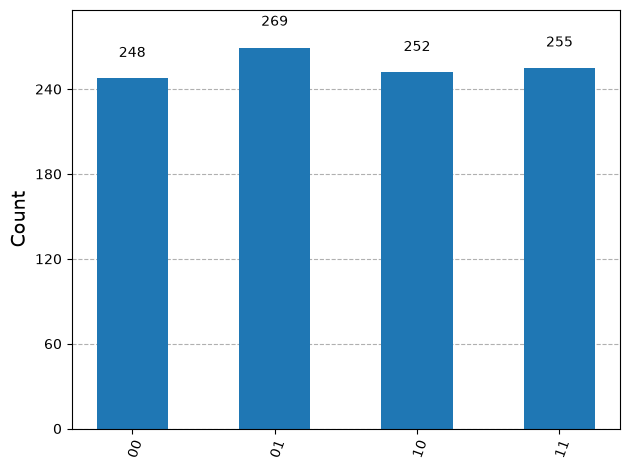

In [5]:
plot_histogram(job.get_counts())
# Circuit simulation has done.
#counts = execute(qc_half_Subtractor, Aer.get_backend('qasm_simulator')).rest

In [6]:
%pip install qiskit-ibm-runtime

Note: you may need to restart the kernel to use updated packages.


In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="VZoz1qUz5CIcOZlf7Vh75w4zfRBafQzhtirJsIXh57VC",
    overwrite=True
)

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform")

qiskit_runtime_service.__init__:WARNING:2026-07-27 10:36:06,593: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


In [9]:
import qiskit
import qiskit_ibm_runtime

print("Qiskit Version:", qiskit.__version__)
print("IBM Runtime Version:", qiskit_ibm_runtime.__version__)

Qiskit Version: 2.5.1
IBM Runtime Version: 0.48.0


In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService

accounts = QiskitRuntimeService.saved_accounts()
print(accounts)

{'default-ibm-quantum-platform': {'channel': 'ibm_quantum_platform', 'url': 'https://cloud.ibm.com', 'token': 'VZoz1qUz5CIcOZlf7Vh75w4zfRBafQzhtirJsIXh57VC', 'verify': True, 'private_endpoint': False}}


In [11]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="VZoz1qUz5CIcOZlf7Vh75w4zfRBafQzhtirJsIXh57VC",
    overwrite=True
)
accounts = QiskitRuntimeService.saved_accounts()
print(accounts)

{'default-ibm-quantum-platform': {'channel': 'ibm_quantum_platform', 'url': 'https://cloud.ibm.com', 'token': 'VZoz1qUz5CIcOZlf7Vh75w4zfRBafQzhtirJsIXh57VC', 'verify': True, 'private_endpoint': False}}


In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform")

print("Connected successfully")

backends = service.backends()
print(f"Number of backends: {len(backends)}")

for backend in backends[:5]:
    print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-07-27 10:37:15,141: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-27 10:37:15,189: Loading instance: open-instance, plan: open


Connected successfully
Number of backends: 3
ibm_fez
ibm_marrakesh
ibm_kingston


In [13]:
import requests

url = "https://auth.quantum-computing.ibm.com/api"

try:
    r = requests.get(url, timeout=10)
    print(r.status_code)
except Exception as e:
    print(e)

HTTPSConnectionPool(host='auth.quantum-computing.ibm.com', port=443): Max retries exceeded with url: /api (Caused by NameResolutionError("HTTPSConnection(host='auth.quantum-computing.ibm.com', port=443): Failed to resolve 'auth.quantum-computing.ibm.com' ([Errno 11001] getaddrinfo failed)"))


In [14]:
%pip install -U qiskit-ibm-runtime

Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip list | findstr qiskit

qiskit                    2.5.1
qiskit-aer                0.17.2
qiskit-ibm-runtime        0.48.0
qiskit-qasm3-import       0.6.0
Note: you may need to restart the kernel to use updated packages.


In [16]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)

0.48.0


In [17]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-07-27 10:37:58,539: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-27 10:38:00,529: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-27 10:38:11,824: Using instance: open-instance, plan: open


<IBMBackend('ibm_marrakesh')>


In [18]:
print(qc_superposition.draw("text"))

     ┌───┐┌─┐    ░ 
q_0: ┤ H ├┤M├────░─
     ├───┤└╥┘┌─┐ ░ 
q_1: ┤ H ├─╫─┤M├─░─
     └───┘ ║ └╥┘ ░ 
c: 2/══════╩══╩════
           0  1    


In [19]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="VZoz1qUz5CIcOZlf7Vh75w4zfRBafQzhtirJsIXh57VC",
    overwrite=True,
)

In [20]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel="ibm_quantum_platform"
)

print(service.backends())

qiskit_runtime_service.__init__:WARNING:2026-07-27 10:38:43,523: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-27 10:38:43,525: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_kingston')>]


In [21]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum_platform")

from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum_platform")

qiskit_runtime_service.__init__:WARNING:2026-07-27 10:39:21,472: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.__init__:WARNING:2026-07-27 10:39:31,498: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default insta

In [22]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum_platform", # ibm_cloud
                               token='VZoz1qUz5CIcOZlf7Vh75w4zfRBafQzhtirJsIXh57VC')

qiskit_runtime_service._discover_account:WARNING:2026-07-27 10:39:31,524: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-27 10:39:38,306: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


In [23]:
print("Qiskit:", qiskit.__version__)
print("IBM Runtime:", qiskit_ibm_runtime.__version__)

Qiskit: 2.5.1
IBM Runtime: 0.48.0


In [24]:
print("Qiskit:", qiskit.__version__)

Qiskit: 2.5.1
